# AMERICAN ELECTRIC PORTFOLIO DESIGN

In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
from scipy.linalg import cho_factor, cho_solve, LinAlgError
from scipy.fft import fft, fftfreq
from scipy.stats import shapiro, skew, kurtosis, ttest_rel, normaltest,jarque_bera
import scipy.stats as st

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

import json
import math

import requests 
from scipy.optimize import minimize, Bounds, LinearConstraint
from typing import Union, Sequence, Tuple

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### USA
The American electricity market operates through a network of regional transmission organizations (RTOs) and independent system operators (ISOs) that coordinate wholesale power trading and grid reliability. Major markets include PJM Interconnection, MISO (Midcontinent ISO), ERCOT (Texas), CAISO, ISO New England, and New York ISO, each running competitive wholesale markets where electricity is priced based on supply and demand. Prices are typically determined through day-ahead and real-time markets using a marginal pricing mechanism called Locational Marginal Pricing (LMP), which reflects generation costs, transmission congestion, and losses at specific nodes or hubs. Electricity prices vary significantly by region, fuel mix (natural gas is often the marginal fuel), weather conditions, demand levels, and transmission constraints. In recent years, price volatility has increased due to natural gas price fluctuations, renewable energy penetration, extreme weather events, and grid constraints, making risk management and hedging strategies essential for market participants.

For data compailingn, down links was used; 
hedge için bu data set kullanılacak 
+ https://www.eia.gov/electricity/wholesale/#history

pjm datasını buradan indirdim ay ay. 
+ https://dataminer2.pjm.com/feed/da_hrl_lmps

Miso datasını günlük bazda buradan indirdim GÜN GÜN evet GÜN GÜN
+ https://www.misoenergy.org/markets-and-operations/real-time--market-data/market-reports/#nt=%2FMarketReportType%3ADay-Ahead%2FMarketReportName%3ADay-Ahead%20Pricing%20(xls)&t=500&p=1&s=MarketReportPublished&sd=desc

ercot datası için 
+ https://www.engieresources.com/historical-pricing-data/

+ https://www.energyonline.com/Data/GenericData.aspx?DataId=22&CAISO___Day-Ahead_Price

In [2]:
dfep1 = pd.read_excel(r"C:\Users\gulis\Desktop\Portfolio Design for Electricty Market\American Electricty Market\Data.xlsx",sheet_name="Sheet1")
dfep = dfep1.drop(["Date"], axis=1)

## PLOTS AND DESCRİBE

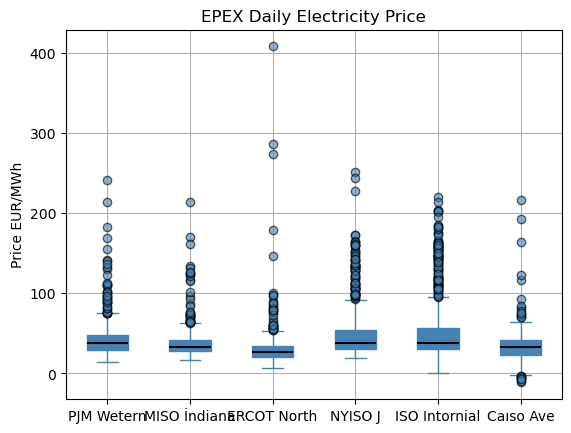

In [3]:
ax = dfep.boxplot(
         patch_artist=True,        # box'ların içini boyamak için şart
         boxprops=dict(facecolor="steelblue", color="steelblue"),
         medianprops=dict(color="black", linewidth=1.5),
         whiskerprops=dict(color="steelblue"),
         capprops=dict(color="steelblue"),
         flierprops=dict(marker='o', markerfacecolor='steelblue', alpha=0.6))
ax.set_ylabel("Price EUR/MWh")
ax.set_title("EPEX Daily Electricity Price")
plt.show()

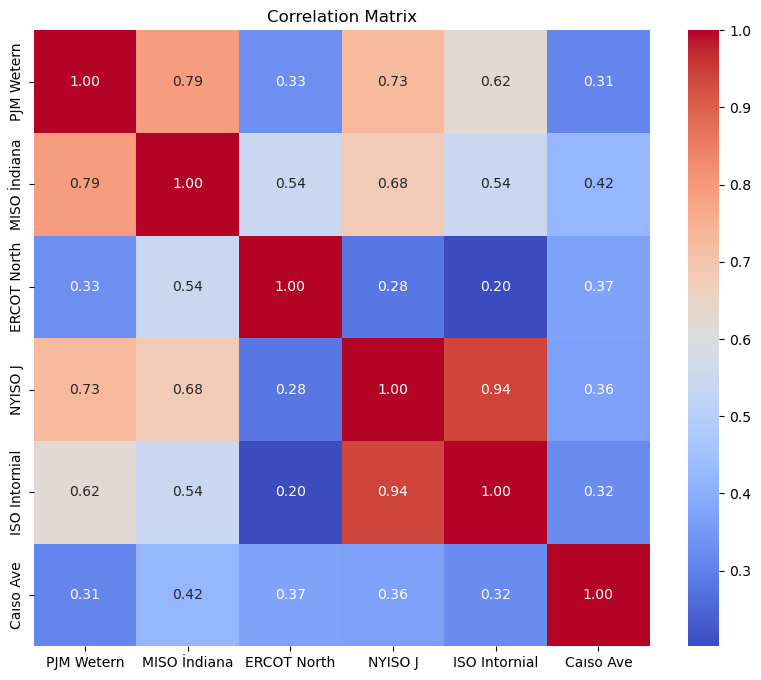

In [33]:
corr = dfep.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.show()

In [34]:
dfep.describe().T.style.format("{:.0f}")

,count,mean,std,min,25%,50%,75%,max
PJM Wetern,731,42,22,14,30,38,48,242
MISO İndiana,731,38,18,16,28,34,42,214
ERCOT North,731,30,24,6,21,27,34,408
NYISO J,731,50,33,20,30,39,55,251
ISO Intornial,731,55,40,0,31,38,56,221
Caıso Ave,731,33,18,-11,24,33,41,217


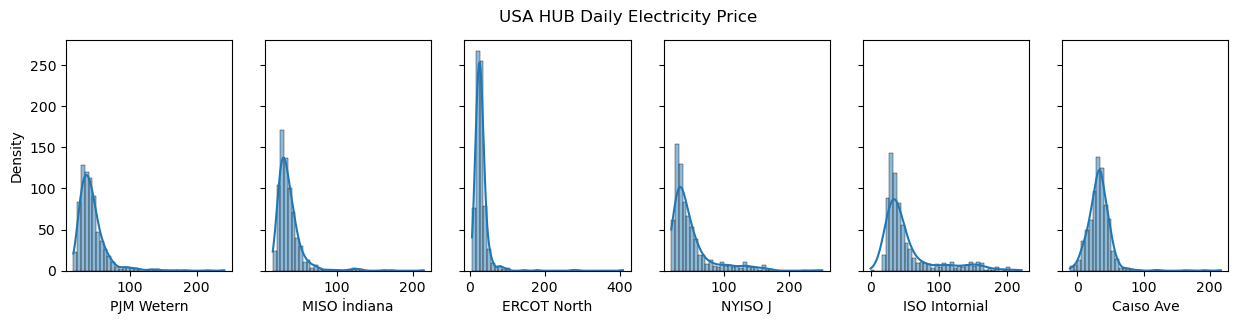

In [35]:
fig, axes = plt.subplots(1, 6, figsize=(15, 3), sharey=True)
sns.histplot(dfep["PJM Wetern"], bins=40, kde=True, ax=axes[0])
sns.histplot(dfep["MISO İndiana"], bins=40, kde=True, ax=axes[1])
sns.histplot(dfep["ERCOT North"], bins=40, kde=True, ax=axes[2])
sns.histplot(dfep["NYISO J"],bins=40, kde=True, ax=axes[3])
sns.histplot(dfep["ISO Intornial"], bins=40, kde=True, ax=axes[4])
sns.histplot(dfep["Caıso Ave"],bins=40, kde=True, ax=axes[5])
axes[0].set_ylabel("Density")
fig.suptitle("USA HUB Daily Electricity Price", fontsize=12)
plt.show()

In [36]:
def stat(series):
    name = series.name             
    data = series.dropna().values   

    stat, p = shapiro(data)
    stat, pk2 = normaltest(data)
    stat, pjb = jarque_bera(data)

    print("values:", name)
    print("shapiro  p-value:", f"{p:.3f}")
    print("kare    p-value:", f"{pk2:.3f}")
    print("jarque  p-value:", f"{pjb:.3f}")

    print("Skewness value :", f"{skew(data):.3f}")
    print("Kurtosis value :", f"{kurtosis(data):.3f}")

    # --- Q-Q Plot ---
    st.probplot(data, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot — {name}")   
    plt.show() 

values: PJM Wetern
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 3.449
Kurtosis value : 19.464


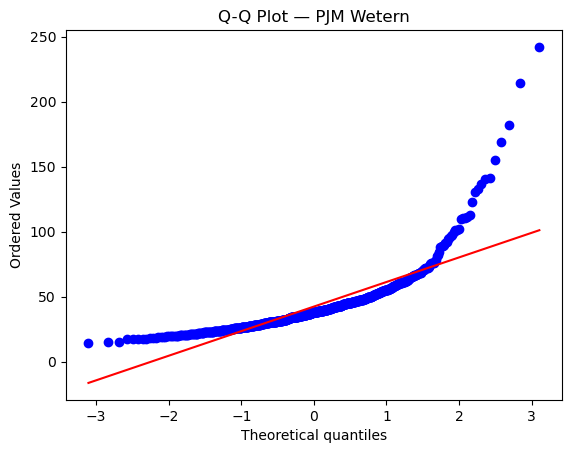

values: MISO İndiana
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 4.050
Kurtosis value : 25.160


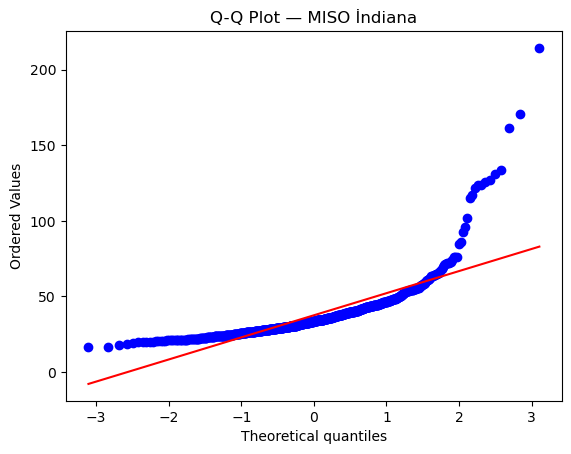

values: ERCOT North
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 9.098
Kurtosis value : 115.979


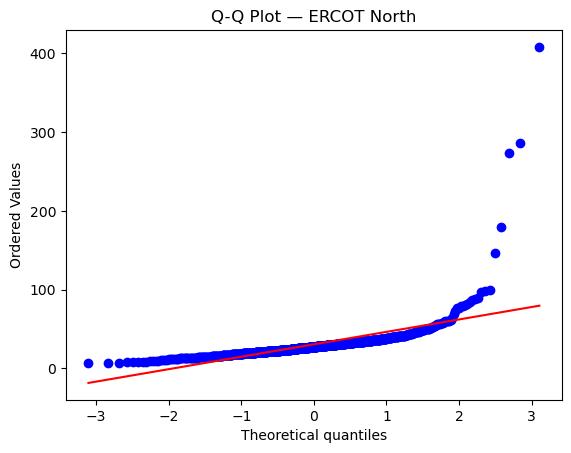

values: NYISO J
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 2.373
Kurtosis value : 6.661


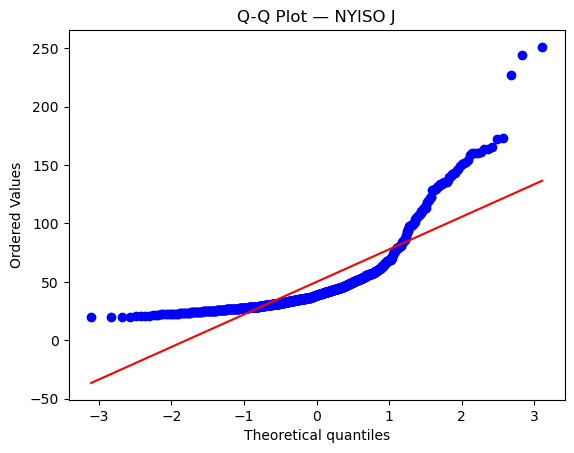

values: ISO Intornial
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 1.898
Kurtosis value : 2.824


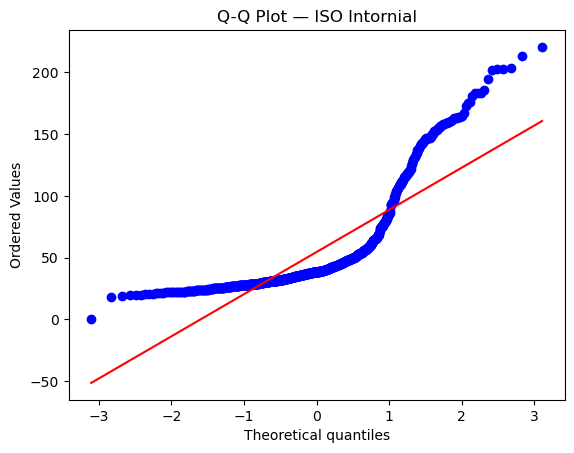

values: Caıso Ave
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 3.085
Kurtosis value : 25.806


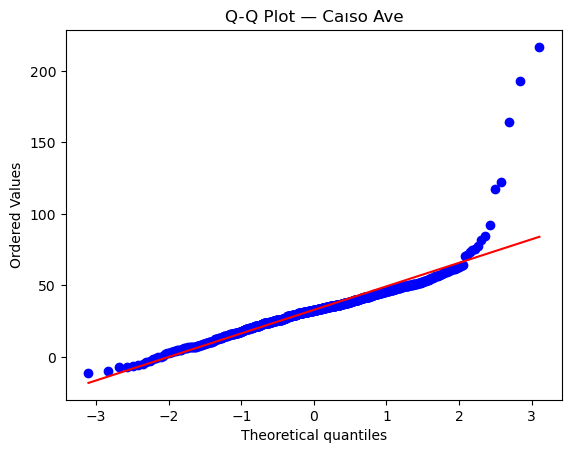

In [37]:
for col in dfep.columns:
    stat(dfep[col])

##  PORTFOLIO DESIGN

In [38]:
def optimalPortfoliononshort(
    df: pd.DataFrame,
    C: float,
    gamma: float,
    lower_bounds: Union[float, Sequence[float]] = 0.0,
    upper_bounds: Union[float, Sequence[float]] = 1.0,
    ridge: float = 1e-8,
) -> Tuple[pd.Series, float, float]:
    """
    Solve:  min_λ  C μ^T λ + γ C^2 λ^T Σ λ
            s.t.   1^T λ = 1,  lb ≤ λ ≤ ub
    df: price levels (rows=time, cols=sources). Returns (λ*, E[X], Var[X]).
    """
    if C <= 0 or gamma <= 0:
        raise ValueError("C and gamma must be > 0.")                              # risk katsayısı ve C >0 olmalı
    X = df.dropna(axis=1, how="all").dropna(axis=0, how="any").astype(float)      # Nan lar atılır
    if X.shape[0] < 2 or X.shape[1] < 1:
        raise ValueError("Not enough data.")                                      # Cov için boyutu minumum 2x2 olmalıdır

    mu = X.mean().to_numpy()                                                      # E[p]
    Sigma = X.cov(ddof=1).to_numpy()                                              # Cov[p], ddof=1 by default
    Sigma = 0.5 * (Sigma + Sigma.T) + ridge * np.eye(len(mu))                     # Symmetrize to dampen numerical asymmetry
    n = len(mu)                                                                   # mu boyutu bulundu

    # expand bounds to vectors
    lb = np.full(n, lower_bounds if np.isscalar(lower_bounds) else np.asarray(lower_bounds, float))  #lower bound
    ub = np.full(n, upper_bounds if np.isscalar(upper_bounds) else np.asarray(upper_bounds, float))  #Upper bound
    if lb.sum() > 1 + 1e-12 or ub.sum() < 1 - 1e-12:
        raise ValueError("Infeasible bounds: need sum(lb) ≤ 1 ≤ sum(ub).")                           #sum(lb) ≤ 1 ≤ sum(ub) şartını manuel test ediyor

    # feasible start: begin at lb, spread remaining mass toward ub
    w0 = lb.copy()                                         # ilk olarak ağırlıklar minimuma eşitleniyor
    rem = 1.0 - w0.sum()                                   # Eşitlik koşulundan yola çıkarak 1'den çıkarılıyor
    if rem > 0:                                            # Ağırlıklar bulunur
        room = np.maximum(ub - w0, 0.0)
        total = room.sum()
        if total > 0: w0 += rem * (room / total)           # toplamın 1 e eşit olduğu sağlanır
    w0 = np.clip(w0, lb, ub)                               # ağırlıkları (w) sınırlar içinde burakır

    def fun(w):  return C * mu @ w + gamma * (C**2) * (w @ Sigma @ w)  #fonksiyon f(w)=Cμ⊤w+γC2w⊤Σw amaç fonk  scaler
    def jac(w):  return C * mu + 2.0 * gamma * (C**2) * (Sigma @ w)    #jacobien  ∇f(w)=Cμ+2γC2Σw   1. Türev   (n,)
    def hess(w): return 2.0 * gamma * (C**2) * Sigma                   #hessian   ∇2f(w)=2γC2Σ      2. Türev   (n,n)

    cons = [LinearConstraint(np.ones((1, n)), 1.0, 1.0)]                # w vektörü ve sınırlar toplamlar 1 e eşit
    bnds = Bounds(lb, ub)                                               # Sınırlar 
    opt  = minimize(fun, w0, method="trust-constr", jac=jac, hess=hess, # Optimizasyon tam olarak burda yapılır ve newton tabanlıdır.
                   bounds=bnds, constraints=cons,
                   options={"maxiter": 500, "gtol": 1e-10, "xtol": 1e-12, "verbose": 0})  
    #gtol=1e-10	Gradyan normu bu değerden küçükse dur.
    #xtol=1e-12	w vektöründeki değişim bu değerden küçükse dur.
    #maxiter=500	Maksimum iterasyon sayısı.
    #verbose=0	Çıktı susturulmuş. 2 yapsan her adımı loglar.
    
    
    if not opt.success:
        raise RuntimeError(f"Optimization failed: {opt.message}")  # algoritmanın neden durduğunu açıklayan yazı "opt.***" gibi türev bilgi verilebilir.

    w = pd.Series(opt.x, index=X.columns, name="No-Short")
    E = C * float(mu @ opt.x)
    V = (C**2) * float(opt.x.T @ Sigma @ opt.x)
    return w, E, V

In [39]:
def optimalPortfolio(df: pd.DataFrame, C: float, gamma: float) -> Tuple[pd.Series, float, float]:
    """
    Interior mean–variance optimizer for procurement weights λ under:
        min_{λ}  C μ^T λ + γ C^2 λ^T Σ λ   s.t.  1^T λ = 1

    Parameters
    ----------
    df : pd.DataFrame
        Historical unit prices (not returns): rows = time, columns = instruments.
        NaNs are dropped row-wise before estimation.
    C : float
        Deterministic total energy requirement (> 0).
    gamma : float
        Risk aversion parameter on variance term (> 0).

    Returns
    -------
    np.ndarray
        The interior optimal weight vector λ* (length = number of columns in df).

    Notes
    -----
    - This returns the *interior* solution, which requires Σ ≻ 0 (SPD).
      If Σ is singular (e.g. a riskless/constant-price instrument or perfect collinearity),
      a ValueError is raised. In that case, remove/merge collinear sources or solve
      the full KKT system with inequality constraints as appropriate.
    - Uses a Cholesky factorization; no explicit matrix inverses are formed.
    """

    #Girdilerden kaynaklı anlamsız hataları verir
    if not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame of historical unit prices.")
    if C <= 0:
        raise ValueError("C must be strictly positive.")
    if gamma <= 0:
        raise ValueError("gamma must be strictly positive.")


    # Nan varsa düşürür ve cov için en az iki satıra ihtiyaç var. 
    df_clean = df.dropna(how="any").astype(float)
    if df_clean.shape[0] < 2 or df_clean.shape[1] < 1:
        raise ValueError("Not enough data after dropping NaNs to estimate μ and Σ.")
    

    mu = df_clean.mean(axis=0).to_numpy()                 # E[p] 
    Sigma = df_clean.cov().to_numpy()                     # Cov[p], ddof=1 by default
    Sigma = 0.5 * (Sigma + Sigma.T)                       # Symmetrize to dampen numerical asymmetry
    n = Sigma.shape[0]                                    # cov boyutu bulundu
    ones = np.ones(n)                                     # Birim vektör (cov boyutunda)

    # Cholesky-based solves to avoid explicit inversion ----- Bu blok, Σ’nın sağlıklı olduğunu garanti altına alıyor
    try:
        cF = cho_factor(Sigma, lower=True, check_finite=True)
    except LinAlgError as e:
        raise ValueError("Covariance matrix Σ is not SPD; interior solution undefined.") from e

    # Solve Σ x = 1 and Σ y = μ
    Sigma_inv_1 = cho_solve(cF, ones)                    #Σ^{−1} * 1
    Sigma_inv_mu = cho_solve(cF, mu)                     #Σ^{−1} * μ

    denom = float(ones @ Sigma_inv_1)                    # 1^T * Σ^{-1} * 1
    if denom <= 0 or not np.isfinite(denom):
        raise ValueError("Numerical issue: 1^T Σ^{-1} 1 must be positive and finite.")

    eta_num = 2.0 * gamma * (C**2) + C * float(ones @ Sigma_inv_mu)    # 2γC^{2} + C1^{⊤}Σ^{−1}μ
    eta = eta_num / denom                                              # [ 2γC^{2} + C1^{⊤}Σ^{−1}μ ] / [ 1^T * Σ^{-1} * 1] 

    # λ* = (1/(2 γ C^2)) [ Σ^{-1}(η 1 - C μ) ] = (1/(2 γ C^2)) (η Σ^{-1}1 - C Σ^{-1}μ)
    lam = (eta * Sigma_inv_1 - C * Sigma_inv_mu) / (2.0 * gamma * (C**2))
    # lam = (C * Sigma_inv_mu - eta * Sigma_inv_1) / (2.0 * gamma * (C**2))

    
    # Optional: enforce the affine constraint numerically (tiny adjustment)
    lam += (1.0 - lam.sum()) * (Sigma_inv_1 / denom)                   # 1^{⊤} * λ = 1 kısıtını mikro ayarla geri oturtur düzeltme amaçlıdır.

    w = pd.DataFrame(lam, index=df.columns )
    E = C * float(mu @ lam)
    V = (C**2) * float(lam @ Sigma @ lam)
    
    return w, E, V 

In [40]:
def results(data):
    import warnings
    warnings.filterwarnings("ignore", category=UserWarning, module="scipy")

    #######################  W ##########################################################################################################
    #####################################################################################################################################
    prices = data.dropna()
    prices.reset_index(drop=True, inplace=True)

    C=10000
    gamma= 1  #risk katsayısı
    n = prices.shape[1]                                    # cov boyutu bulundu
    upper_bounds = np.full(n, 0.3)  
    lower_bounds = np.full(n, -0.3) 
        
  
    w1, E1, V1 = optimalPortfoliononshort(prices, C=C, gamma=gamma )
    w2, E2, V2 = optimalPortfoliononshort(prices, C=C, gamma=gamma,  upper_bounds=upper_bounds , lower_bounds=lower_bounds)
    w3, E3, V3 = optimalPortfolio(prices,C,gamma)
    

    w1_df = w1.copy()
    w2_df = w2.copy()
    w3_df = w3.copy()
    
    weights_df = pd.concat([w1_df, w2_df,w3_df], axis=1)
    weights_df.columns = ["P1 non-short","P2 with limited UB-LB","P3 with short"]
    weights_df = weights_df.round(2)
    
    plt.figure(figsize=(10,8))
    sns.heatmap(weights_df, annot=True, fmt=".2f", cmap="coolwarm" , square=True)
    plt.title("Weight Matrix")
    plt.show()

    #######################  MONTE CARLO  ###############################################################################################
    #####################################################################################################################################

    mu = prices.mean().to_numpy()
    Sigma = prices.cov(ddof=1).to_numpy()
    Sigma = 0.5 * (Sigma + Sigma.T)
    
    lam1 = weights_df["P1 non-short"].to_numpy()
    lam2 = weights_df["P2 with limited UB-LB"].to_numpy()
    lam3 = weights_df["P3 with short"].to_numpy()     
    
    n_sim = 10_000
    rng = np.random.default_rng(42)
    p = rng.multivariate_normal(mu, Sigma, size=n_sim)  # ortalama maliyet üretildi. Rastgele ama mantıklı. 
    
    # Toplam maliyet
    X1 = C * (p @ lam1) #P1 non-short
    X2 = C * (p @ lam2) #P2 with limited UB-LB
    X3 = C * (p @ lam3) #P3 with short

    # İstatistikler
    
    P1E, P1R = float(X1.mean()), float(X1.std(ddof=0))
    P2E, P2R = float(X2.mean()), float(X2.std(ddof=0))
    P3E, P3R = float(X3.mean()), float(X3.std(ddof=0))

    #######################   E V CALCULATION ###########################################################################################
    #####################################################################################################################################
    
    perf_mc_df = pd.DataFrame({
        "Expected Cost (MC)": [P1E, P2E, P3E],
        "Expected Cost":      [E1, E2, E3], 
        "Risk (Std, MC)":     [P1R, P2R, P3R],
        "Risk (Std)": [np.sqrt(V1), np.sqrt(V2),np.sqrt(V3)]}, 
        index=["P1 Non-Short", "P2 UB-LB", "P3 With Short"])
    display(perf_mc_df.style.format("{:,.0f}"))
    
    return {
    "prices": prices,
    "weights_df": weights_df,
    "perf_mc_df": perf_mc_df,
    "w1": w1, "w2": w2, "w3": w3,
    "E1": E1, "E2": E2, "E3": E3,
    "V1": V1, "V2": V2, "V3": V3,
    }

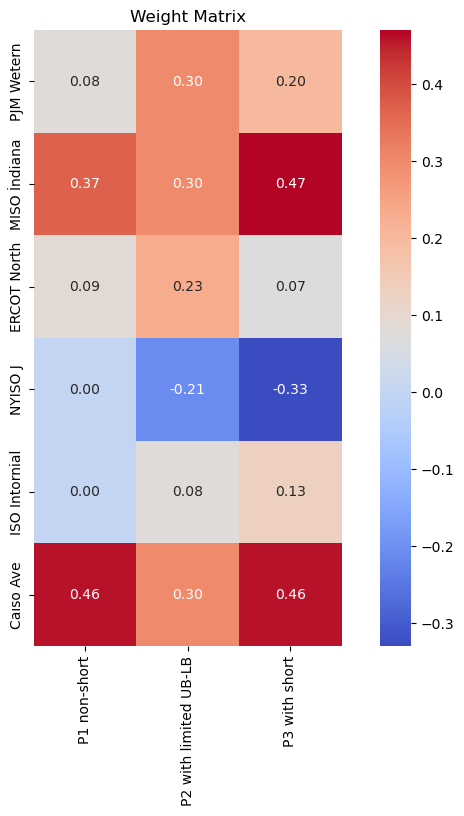

,Expected Cost (MC),Expected Cost,"Risk (Std, MC)",Risk (Std)
P1 Non-Short,"351,870","351,200","153,822","151,437"
P2 UB-LB,"347,420","348,247","154,549","152,144"
P3 With Short,"339,849","339,320","148,255","146,128"


In [41]:
out = results(dfep)

# Efficient Frontier 

In [42]:
prices=dfep
C=10000
gamma = 1

In [43]:
# =========================================================
# EFFICIENT FRONTIER - 4 PORTFOLIO DESIGNS
# Existing objects assumed:
# prices, Cc
# optimalPortfoliononshort(...)
# optimalPortfolio(...)
# =========================================================

n = prices.shape[1]

# Bounds used in your previous setup
ub_02 = np.full(n, 0.3)
lb_m02 = np.full(n, -0.3)

ub_03 = np.full(n, 3)
lb_m03 = np.full(n, -3)

# Wider gamma grid -> more points on the frontier
gamma_grid = np.logspace(-5, 1, 30)

def build_frontier_nonshort(prices, C, gamma_grid, lower_bounds=0.0, upper_bounds=1.0):
    rows = []

    for g in gamma_grid:
        try:
            w, E, V = optimalPortfoliononshort(
                prices,
                C=C,
                gamma=float(g),
                lower_bounds=lower_bounds,
                upper_bounds=upper_bounds
            )
            rows.append([float(g), float(np.sqrt(V)), float(E)])
        except Exception:
            pass

    df_front = pd.DataFrame(rows, columns=["gamma", "risk", "cost"])
    df_front = df_front.replace([np.inf, -np.inf], np.nan).dropna()

    # duplicate risk values can break the visual shape a bit
    df_front = df_front.sort_values("risk").drop_duplicates(subset="risk")

    return df_front


def build_frontier_short(prices, C, gamma_grid):
    rows = []

    for g in gamma_grid:
        try:
            w, E, V = optimalPortfolio(
                prices,
                C=C,
                gamma=float(g)
            )
            rows.append([float(g), float(np.sqrt(V)), float(E)])
        except Exception:
            pass

    df_front = pd.DataFrame(rows, columns=["gamma", "risk", "cost"])
    df_front = df_front.replace([np.inf, -np.inf], np.nan).dropna()
    df_front = df_front.sort_values("risk").drop_duplicates(subset="risk")

    return df_front


def get_current_portfolios(prices, C, gamma_point):
    n = prices.shape[1]
    ub = np.full(n,  0.3)
    lb = np.full(n, -0.3)
    ub1 = np.full(n,  3)
    lb1 = np.full(n, -3)
    
    w1, E1, V1 = optimalPortfoliononshort(prices, C=C, gamma=gamma_point)
    w2, E2, V2 = optimalPortfoliononshort(prices, C=C, gamma=gamma_point, lower_bounds=lb,  upper_bounds=ub)
    w3, E3, V3 = optimalPortfoliononshort(prices, C=C, gamma=gamma_point, lower_bounds=lb1, upper_bounds=ub1)

    pts = pd.DataFrame({
        "Portfolio": [
            "P1 Non-Short",
            "P2 Limited LB-UB",
            "P3 With Short"
        ],
        "risk": [
            float(np.sqrt(V1)),
            float(np.sqrt(V2)),
            float(np.sqrt(V3))
        ],
        "cost": [
            float(E1),
            float(E2),
            float(E3)
        ]
    })

    return pts

In [44]:
# ---------- Build frontiers ----------
front1 = build_frontier_nonshort(prices, C, gamma_grid, lower_bounds=0.0, upper_bounds=1.0)
front2 = build_frontier_nonshort(prices, C, gamma_grid, lower_bounds=lb_m02, upper_bounds=ub_02)
front3 = build_frontier_nonshort(prices, C, gamma_grid, lower_bounds=lb_m03, upper_bounds=ub_03)

# Choose one gamma to highlight current portfolio points
gamma_point = 1.0
pts = get_current_portfolios(prices, C, gamma_point)

# ---------- Check how many valid points each frontier has ----------
print("P1 valid points:", len(front1))
print("P2 valid points:", len(front2))
print("P3 valid points:", len(front3))

P1 valid points: 30
P2 valid points: 30
P3 valid points: 30


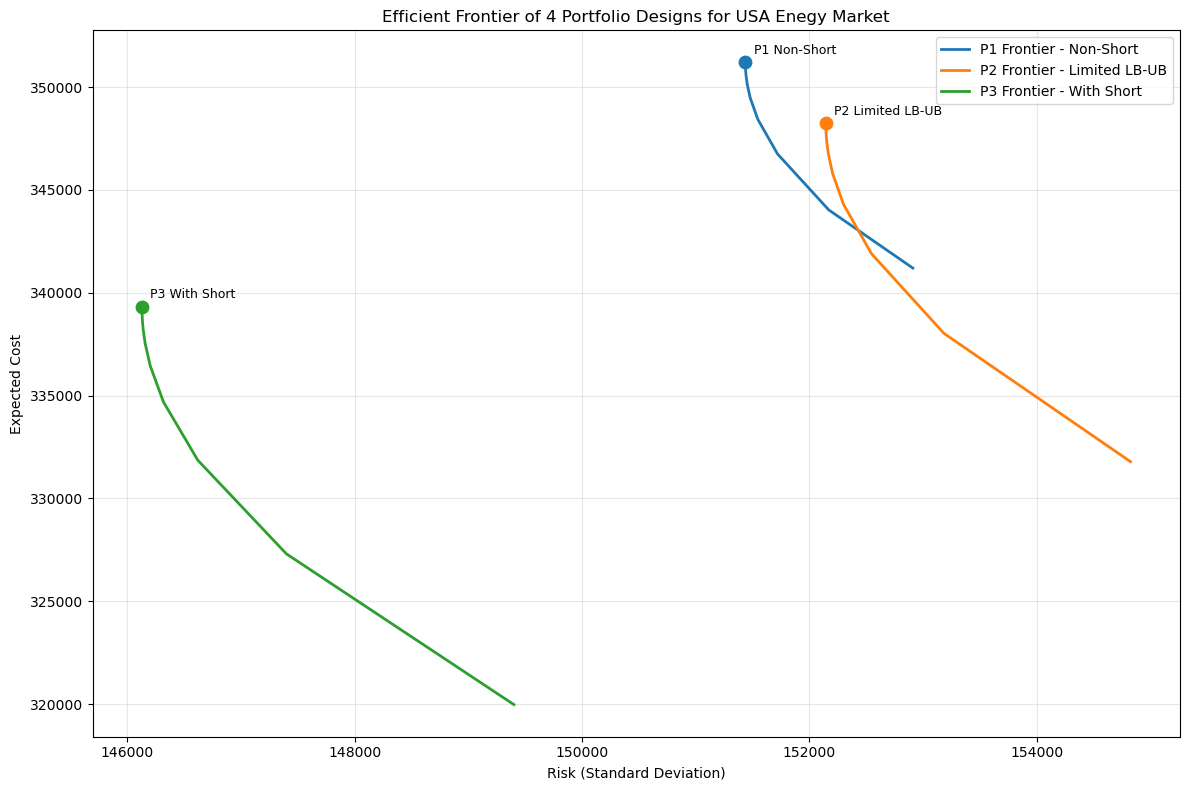

In [45]:
# ---------- Plot ----------
plt.figure(figsize=(12, 8))

if len(front1) > 1:
    plt.plot(front1["risk"], front1["cost"], linewidth=2, label="P1 Frontier - Non-Short")
if len(front2) > 1:
    plt.plot(front2["risk"], front2["cost"], linewidth=2, label="P2 Frontier - Limited LB-UB")
if len(front3) > 1:
    plt.plot(front3["risk"], front3["cost"], linewidth=2, label="P3 Frontier - With Short")


# highlight current selected gamma portfolios
for _, row in pts.iterrows():
    plt.scatter(row["risk"], row["cost"], s=80)
    plt.annotate(
        row["Portfolio"],
        (row["risk"], row["cost"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Risk (Standard Deviation)")
plt.ylabel("Expected Cost")
plt.title("Efficient Frontier of 4 Portfolio Designs for USA Enegy Market")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# HEDGE 

In [86]:
dfhe = pd.read_excel(r"C:\Users\gulis\Desktop\Portfolio Design for Electricty Market\American Electricty Market\USA Future.xlsx",sheet_name="Sheet3")
#dfhe = dfhe.drop(columns=["Delivery Date (CET)"])

In [87]:
F1 = dfhe[["Date","Mid C "]]
F2 = dfhe[["Date","PJM WH "]]
F3 = dfhe[["Date","SP15 LMP"]]

In [88]:
F1 = F1.dropna()
F2 = F2.dropna()
F3 = F3.dropna()

In [89]:
w1 = out["w1"]
w2 = out["w2"]
w3 = out["w3"]

In [90]:
S_dict = {
    "Date":(dfep1["Date"]),
    "P1 non-short": (dfep * w1.squeeze()).sum(axis=1),
    "P2 with limited UB-LB": (dfep * w2.squeeze()).sum(axis=1),
    "P3 with short": (dfep * w3.squeeze()).sum(axis=1)}
dfg =pd.DataFrame.from_dict(S_dict)

In [91]:
data1 =  F1.merge(dfg, how="left", on="Date")
data2 =  F2.merge(dfg, how="left", on="Date")
data3 =  F3.merge(dfg, how="left", on="Date")

In [92]:
S_dict1 = { "P1 non-short": (data1["P1 non-short"]),
            "P2 with limited UB-LB": (data1["P2 with limited UB-LB"]),
            "P3 with short": (data1["P3 with short"])}

S_dict2 = { "P1 non-short": (data2["P1 non-short"]),
            "P2 with limited UB-LB": (data2["P2 with limited UB-LB"]),
            "P3 with short": (data2["P3 with short"])}

S_dict3 = { "P1 non-short": (data3["P1 non-short"]),
            "P2 with limited UB-LB": (data3["P2 with limited UB-LB"]),
            "P3 with short": (data3["P3 with short"])}

In [93]:
F1 = data1["Mid C "]
F2 = data2["PJM WH "]
F3 = data3["SP15 LMP"]

In [94]:
F2.iloc[0]

np.float64(62.65)

In [95]:
def run_mvh_block(S_dict, F, C=10000):

    rows = []

    for name, S in S_dict.items():

        df_h = pd.concat([S.rename("S"), F.rename("F")], axis=1).dropna()

        d = df_h.diff().dropna()
        h = d["S"].cov(d["F"]) / d["F"].var()

        X_unhedged = C * df_h["S"]
        X_hedged   = C * df_h["S"] - (h * C) * (df_h["F"] - df_h["F"].iloc[0])

        E_un  = X_unhedged.mean()
        Std_un = X_unhedged.std(ddof=0)
        E_h   = X_hedged.mean()
        Std_h  = X_hedged.std(ddof=0)

        rr = 100 * (1 - Std_h / Std_un)

        rows.append([name, float(h), E_un, E_h, Std_un, Std_h, rr])

    hedge_results = pd.DataFrame(rows, columns=[
        "Portfolio", "h*", "E (Unhedged)", "E (Hedged)",
        "Std (Unhedged)", "Std (Hedged)", "Risk Reduction %"
    ]).set_index("Portfolio")

    return hedge_results.style \
        .format("{:,.0f}", subset=["E (Unhedged)","Std (Unhedged)","E (Hedged)","Std (Hedged)"]) \
        .format("{:.2f}", subset=["h*"]) \
        .format("{:.2f}", subset=["Risk Reduction %"])

In [96]:
results = run_mvh_block(S_dict1, F1, C=10000)
print("Mid C ")
display(results)

Mid C 


,h*,E (Unhedged),E (Hedged),Std (Unhedged),Std (Hedged),Risk Reduction %
Portfolio,,,,,,
P1 non-short,0.06,"358,947","369,060","148,649","129,261",13.04
P2 with limited UB-LB,0.06,"354,514","364,212","150,889","135,436",10.24
P3 with short,0.07,"346,088","356,244","142,937","123,847",13.36


In [97]:
results = run_mvh_block(S_dict2, F2, C=10000)
print("PJM WH ")
display(results)

PJM WH 


,h*,E (Unhedged),E (Hedged),Std (Unhedged),Std (Hedged),Risk Reduction %
Portfolio,,,,,,
P1 non-short,0.26,"373,839","402,673","164,142","125,326",23.65
P2 with limited UB-LB,0.29,"368,697","400,878","169,621","126,843",25.22
P3 with short,0.25,"359,691","386,930","157,679","125,452",20.44


In [98]:
results = run_mvh_block(S_dict3, F3, C=10000)
print("SP15 LMP")
display(results)

SP15 LMP


,h*,E (Unhedged),E (Hedged),Std (Unhedged),Std (Hedged),Risk Reduction %
Portfolio,,,,,,
P1 non-short,0.66,"360,183","468,500","148,695","118,810",20.10
P2 with limited UB-LB,0.71,"355,604","470,710","151,245","139,310",7.89
P3 with short,0.66,"347,160","455,551","143,068","118,624",17.09
